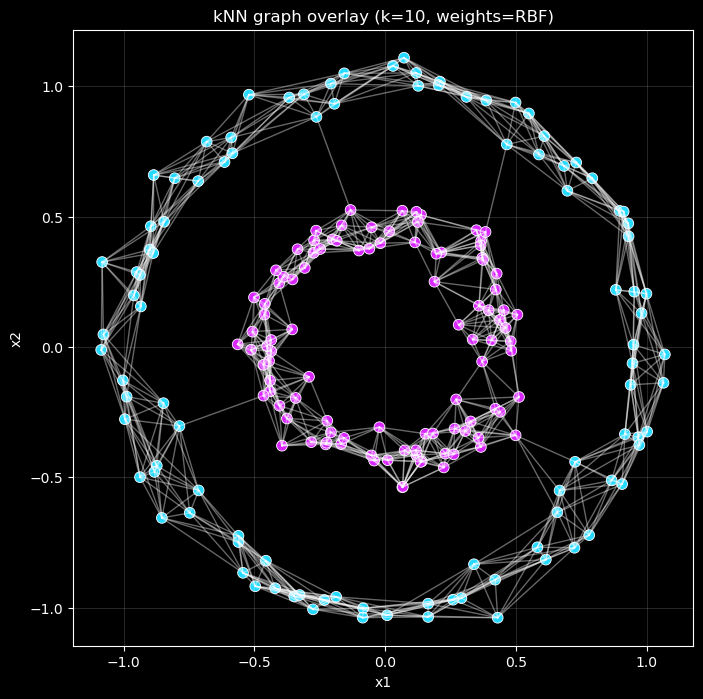

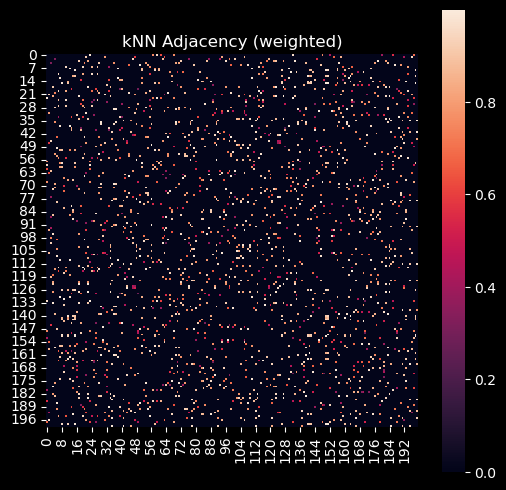

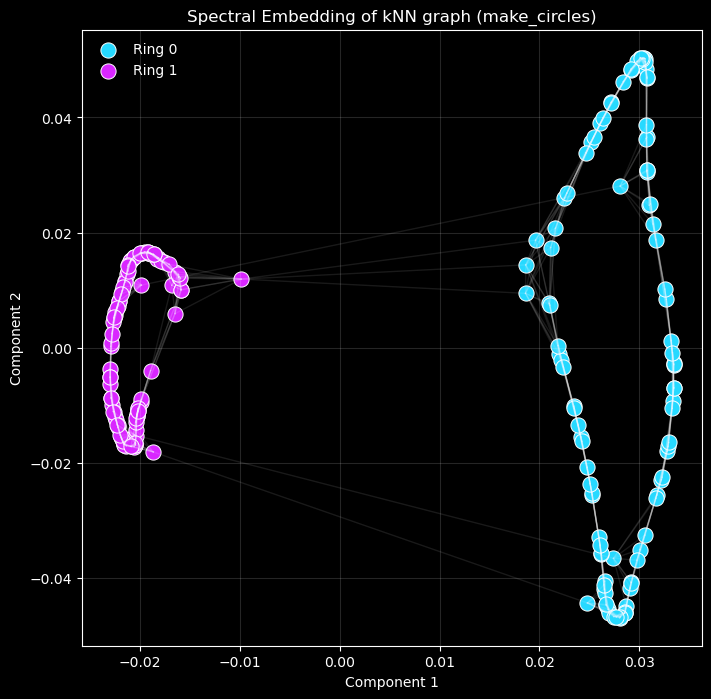

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("dark_background")

import networkx as nx
from sklearn.datasets import make_circles
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import SpectralEmbedding

# ============================================================
# 1) Make Circles dataset
# ============================================================
n_samples = 200
X_raw, y = make_circles(n_samples=n_samples, factor=0.45, noise=0.06, random_state=42)

# ============================================================
# 2) Build kNN graph (weighted adjacency)
#    - We connect each point to its k nearest neighbors.
#    - Weight options:
#        (A) binary: w_ij = 1
#        (B) RBF:    w_ij = exp(-||xi-xj||^2 / (2*sigma^2))
# ============================================================
k = 10
use_rbf_weights = True

nbrs = NearestNeighbors(n_neighbors=k+1, algorithm="auto").fit(X_raw)
distances, indices = nbrs.kneighbors(X_raw)  # includes self at position 0

# Estimate sigma from neighbor distances (robust-ish heuristic)
# Use the median distance to the k-th neighbor across points
sigma = np.median(distances[:, -1]) + 1e-12

n = X_raw.shape[0]
A = np.zeros((n, n), dtype=float)

for i in range(n):
    for jj in range(1, k+1):  # skip self at jj=0
        j = indices[i, jj]
        d = distances[i, jj]
        if use_rbf_weights:
            w = np.exp(-(d**2) / (2 * sigma**2))
        else:
            w = 1.0
        A[i, j] = max(A[i, j], w)
        A[j, i] = max(A[j, i], w)  # symmetrize

# Build networkx graph from adjacency
G = nx.from_numpy_array(A)

# (Optional) ensure connected; if not, bump k
# print("Connected:", nx.is_connected(G))

# ============================================================
# 3) Plots: raw data + kNN graph overlay
# ============================================================
# colors for the two rings
ring_cmap = plt.get_cmap("cool")
ring_colors = [ring_cmap(0.15), ring_cmap(0.85)]
node_colors = [ring_colors[int(cls)] for cls in y]

plt.figure(figsize=(8, 8))
# draw edges lightly
for i, j in G.edges():
    plt.plot([X_raw[i, 0], X_raw[j, 0]],
             [X_raw[i, 1], X_raw[j, 1]],
             color="white", alpha=0.4, linewidth=1)

# draw nodes on top
plt.scatter(X_raw[:, 0], X_raw[:, 1], s=60, c=node_colors, edgecolors="white", linewidths=0.6)
plt.title(f"kNN graph overlay (k={k}, weights={'RBF' if use_rbf_weights else 'binary'})", color="white")
plt.xlabel("x1", color="white")
plt.ylabel("x2", color="white")
plt.grid(alpha=0.15)
plt.show()

# ============================================================
# 4) Adjacency heatmap
# ============================================================
plt.figure(figsize=(6, 6))
sns.heatmap(A, square=True)
plt.title("kNN Adjacency (weighted)", color="white")
plt.show()

# ============================================================
# 5) Spectral Embedding on the kNN adjacency (precomputed affinity)
# ============================================================
embedder = SpectralEmbedding(n_components=2, affinity="precomputed", random_state=42)
X_emb = embedder.fit_transform(A)

plt.figure(figsize=(8, 8))

# draw edges first (in embedding space)
for i, j in G.edges():
    plt.plot([X_emb[i, 0], X_emb[j, 0]],
             [X_emb[i, 1], X_emb[j, 1]],
             color="white", alpha=0.10, linewidth=1)

# draw nodes by ring label
for cls in np.unique(y):
    mask = (y == cls)
    plt.scatter(X_emb[mask, 0], X_emb[mask, 1],
                s=120,
                c=[ring_colors[int(cls)]],
                edgecolors="white",
                linewidths=0.7,
                label=f"Ring {cls}")

plt.title("Spectral Embedding of kNN graph (make_circles)", color="white")
plt.xlabel("Component 1", color="white")
plt.ylabel("Component 2", color="white")
plt.legend(frameon=False)
plt.grid(alpha=0.15)
plt.show()